# 01. CNN과 합성곱 연산

## CNN이란?

CNN(Convolutional Neural Network, 합성곱 신경망)은 **이미지처럼 격자 형태로 배치된 데이터에서 중요한 특징을 자동으로 찾아내는 신경망**이다. 이미지 분류, 객체 탐지, 얼굴 인식, OCR 등 컴퓨터 비전 문제에 주로 사용한다.

일반적인 완전연결 신경망은 이미지를 1차원으로 펼쳐 처리하므로 픽셀의 상하좌우 위치 관계를 활용하기 어렵고 파라미터 수도 많아진다. CNN은 작은 필터인 **커널(kernel)** 을 이미지 위에서 이동시키며 가까운 픽셀들의 관계를 확인한다. 같은 커널을 이미지 전체에 공유하므로 공간 구조를 유지하면서 파라미터 수를 줄일 수 있다.

CNN은 처음부터 사물 전체를 알아보는 것이 아니다. 초기 층에서는 선과 모서리 같은 단순한 특징을 찾고, 다음 층에서는 질감과 부분 모양을 찾으며, 깊은 층에서는 이 특징들을 조합해 사물을 구분한다. 이때 어떤 특징을 찾을지는 사람이 직접 지정하지 않고 학습 과정에서 커널의 가중치가 자동으로 결정된다.

기본 흐름은 **이미지 입력 → 합성곱으로 특징 추출 → 활성화 함수 적용 → 풀링으로 크기 축소 → 추출한 특징으로 분류**이다.

이 노트북은 `(N, C, H, W)` 입력, 커널, feature map, stride, padding, pooling, 분류 모델의 shape 흐름을 그림과 코드로 확인한다.

## CNN의 전체 처리 흐름

![CNN의 전체 구조](https://d.pr/i/nSRcmK+)

CNN은 앞부분의 **합성곱층과 풀링층**에서 이미지 특징을 추출하고, 뒷부분의 **완전연결층**에서 추출한 특징을 이용해 클래스를 판단한다.

![CNN이 계층적으로 특징을 추출하는 과정](https://d.pr/i/yCJQyk+)

입력에 가까운 층은 선과 모서리처럼 단순한 특징을 찾고, 깊은 층은 질감과 부분 모양을 조합해 더 복잡한 특징을 만든다. 필터 값은 사람이 정하는 것이 아니라 손실을 줄이는 방향으로 학습된다.


### 커널 이동과 feature map

![필터 하나를 적용할 때 출력값 하나가 계산되는 과정](https://d.pr/i/UIgjFa+)

커널과 겹친 입력 영역의 원소를 서로 곱해 모두 더하면 feature map의 값 하나가 된다. 같은 커널을 다음 위치로 이동하며 이 계산을 반복한다.

![합성곱 커널이 입력을 이동하는 과정](https://miro.medium.com/v2/resize:fit:640/format:webp/1*Ff6mG3aPdWFkjb6hZPy3Xw.gif)

출처: [Towards Data Science, Convolutional Neural Network](https://towardsdatascience.com/convolutional-neural-network-1368ee2998d3)

### stride와 padding
- Stride: 커널이 이미지 위에서 한 번에 이동하는 칸 수. 값이 클수록 출력 이미지가 작아짐.
- Padding: 이미지 가장자리에 0 등의 값을 추가하는 것. 경계 정보를 보존하고 출력 크기를 조절함.

![stride에 따른 커널 이동 간격](https://miro.medium.com/v2/resize:fit:588/format:webp/1*BMngs93_rm2_BpJFH2mS0Q.gif)

![padding을 적용한 합성곱](https://miro.medium.com/v2/resize:fit:640/format:webp/1*1okwhewf5KCtIPaFib4XaA.gif)

출처: [Towards Data Science, Intuitively Understanding Convolutions for Deep Learning](https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1)

### pooling과 입력 채널

![합성곱 뒤에 pooling을 적용하는 흐름](https://d.pr/i/5S0uPJ+)

Pooling은 작은 영역을 대표값으로 요약해 feature map의 높이와 너비를 줄인다. 학습할 가중치는 없으며, 계산량을 줄이고 작은 위치 변화에 덜 민감하게 만든다.

![max pooling으로 공간 크기를 줄이는 과정](https://d.pr/i/I9XtBk+)

출처: [Stanford UFLDL, Pooling](http://ufldl.stanford.edu/tutorial/supervised/Pooling/)

![입력 채널 전체를 보는 커널](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*8dx6nxpUh2JqvYWPadTwMQ.gif)

RGB 입력에 사용하는 커널 한 개의 깊이는 입력 채널 수 3과 같다. 세 채널에서 계산한 값을 더해 출력 feature map 한 장을 만든다.

![여러 입력 채널의 합성곱 결과를 합치는 과정](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*CYB2dyR3EhFs1xNLK8ewiA.gif)

![여러 필터가 여러 출력 feature map을 만드는 과정](https://d.pr/i/RMxib5+)

필터 한 개는 출력 채널 한 개를 만든다. 따라서 `Conv2d(in_channels=3, out_channels=8)`은 RGB 채널 전체를 보는 서로 다른 필터 8개로 출력 feature map 8장을 만든다.

출처: [Towards Data Science, Intuitively Understanding Convolutions for Deep Learning](https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1), [CS231n Convolutional Networks](https://cs231n.github.io/convolutional-networks/)


## 입력과 출력 shape 공식

PyTorch 이미지 배치는 `(N, C, H, W)` 순서이다.

- `N`: 한 번에 처리하는 이미지 수
- `C`: 입력 채널 수. 흑백은 1, RGB는 3이다.
- `H`, `W`: 이미지 높이와 너비
- Conv2d 가중치 shape: `(out_channels, in_channels / groups, kH, kW)`

한 공간 축의 출력 크기는 다음과 같다.

`floor((input + 2*padding - dilation*(kernel-1) - 1) / stride + 1)`

`padding=kernel//2`, `stride=1`, 홀수 커널이면 보통 공간 크기가 유지된다.


### 1. 출력 크기 공식과 실제 shape 검산

Conv2d 출력 크기 공식과 PyTorch의 실제 출력 shape가 일치하는지 검산한다.


In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 모델을 만들기 전에 한 공간 축의 출력 크기를 계산하는 함수
def conv_output_size(input_size, kernel_size, stride=1, padding=0, dilation=1):

    return math.floor(
        (input_size + 2 * padding - dilation * (kernel_size - 1) - 1)
        / stride
        + 1
    )

# nn.Conv2d
# - 파이토치에서 이미지나 2차원 데이터를 처리할 때 사용하는 도구
# - 합성곱 연산 수행하는 층(layer)이다.
conv_demo = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    stride=2,
    padding=1,
)

# n = 4 -> 이미지 4장
# c = 3 -> RGB 3채널
# h = 32 -> 높이 32px
# w = 32 -> 너비 32px
nchw_batch = torch.randn(4, 3, 32, 32)

# conv_demo 모델을 호출하여 내부 forward() 실행
# -> 결과 반환
conv_output = conv_demo(nchw_batch)

# 모델 결과로 예쌍되는
# 이미지 개수, 출력 채널 수, 높이, 너비를 직접 만든 공식에 넣어서 확인
expected_hw = conv_output_size(32, kernel_size=3, stride=2, padding=1)

print("input:", tuple(nchw_batch.shape))
print("expected H=W:", expected_hw)
print("actual output:", tuple(conv_output.shape))


# H, W가 16인 이유:
# - 32 + (padding 1 *2) -> 34 == 가로/세로 34px
# - 커널 3x3, stride 2 -> 커널이 한 방향을 16번씩 움직임 -> 16 x 16
# 결론:
# - input: (4, 3, 32, 32)
# - output: (4, 8, 16, 16)

input: (4, 3, 32, 32)
expected H=W: 16
actual output: (4, 8, 16, 16)


### 2. 입력, 커널, feature map을 한 화면에서 비교

수직 경계 커널이 입력의 밝기 변화 위치를 feature map에 어떻게 강조하는지 시각화한다.


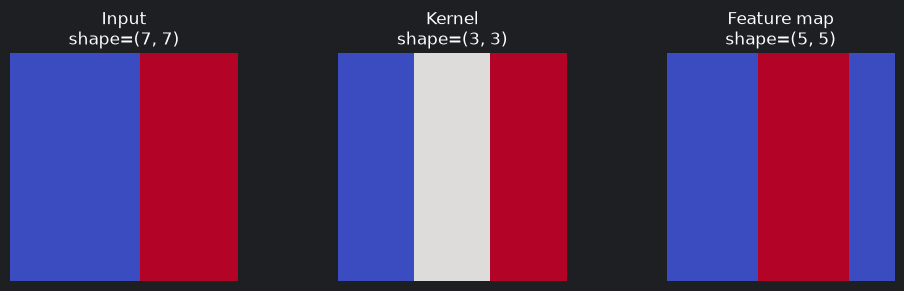

In [2]:
# 왼쪽은 0, 오른쪽은 1인 7x7
edge_input = torch.zeros(1, 1, 7, 7)
edge_input[:, :, :, 4:] = 1.0

# 왼쪽과 오른쪽 픽셀 차이를 계산하는 수직 경계 커널 생성
vertical_edge_kernel = torch.tensor(
    [[[[-1.0, 0.0, 1.0],
       [-1.0, 0.0, 1.0],
       [-1.0, 0.0, 1.0]]]]
)

# conv2d 합성곱 신경망 모델 생성
edge_feature_map = F.conv2d(
    edge_input,
    vertical_edge_kernel,
    padding=0
)

figure, axes = plt.subplots(1, 3, figsize=(10, 3))
visual_items = [
    (edge_input[0, 0], "Input\nshape=(7, 7)"),
    (vertical_edge_kernel[0, 0], "Kernel\nshape=(3, 3)"),
    (edge_feature_map[0, 0], "Feature map\nshape=(5, 5)"),
]
for axis, (image, title) in zip(axes, visual_items):
    axis.imshow(image, cmap="coolwarm")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()


### 3. padding과 stride 전후 shape 비교

같은 입력과 커널에서 padding과 stride만 바꿨을 때 feature map의 크기와 해상도가 어떻게 달라지는지 비교한다.


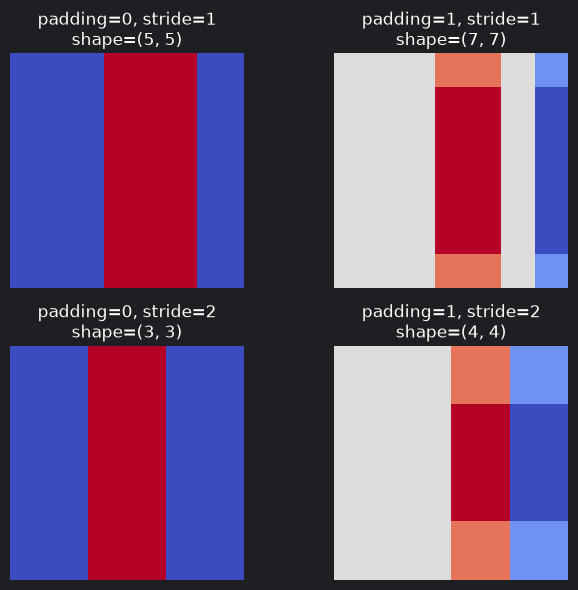

In [3]:
convolution_settings = [
    {"padding": 0, "stride": 1},
    {"padding": 1, "stride": 1},
    {"padding": 0, "stride": 2},
    {"padding": 1, "stride": 2},
]

padding_stride_outputs = []
for setting in convolution_settings:
    feature_map = F.conv2d(
        edge_input,
        vertical_edge_kernel,
        padding=setting["padding"],
        stride=setting["stride"],
    )
    padding_stride_outputs.append(feature_map)

figure, axes = plt.subplots(2, 2, figsize=(7, 6))
for axis, setting, feature_map in zip(
    axes.flat, convolution_settings, padding_stride_outputs
):
    map_2d = feature_map[0, 0]
    axis.imshow(map_2d, cmap="coolwarm")
    axis.set_title(
        f"padding={setting['padding']}, stride={setting['stride']}\n"
        f"shape={tuple(map_2d.shape)}"
    )
    axis.axis("off")
plt.tight_layout()
plt.show()


## 커널과 채널

한 커널은 입력의 모든 채널을 함께 본다. RGB 입력에 커널 8개를 사용하면 가중치 shape는 `(8, 3, kH, kW)`이고 출력 채널은 8개가 된다. 같은 커널이 모든 위치에 적용되는 **가중치 공유**가 CNN의 핵심이다.


### 4. 커널 shape와 파라미터 수

Conv2d의 커널 shape에서 입력 채널, 출력 채널, 커널 크기를 읽고 파라미터 수를 검산한다.


In [4]:
# nn.Conv2d의 파라미터 중 W(가중치)는
# 이미지의 특징을 뽑아내는 필터 자체의 값

# 출력채널, 입력채널, 커널 높이, 커널 너비
# (out_channels=8, in_channels=3, kH=3, kW=3)
weight_shape = tuple(conv_demo.weight.shape)

# b(편향)
# - 필터(커널)를 다 거치고 나온 최종 결과물에 더해주는 보정값
# - 보통 출력 채널수와 개수가 같음
bias_shape = tuple(conv_demo.bias.shape)

# 예상되는 파라미터 개수
expected_parameters = 8 * 3 * 3 * 3 + 8 # 224개
actual_parameters = sum(parameter.numel() for parameter in conv_demo.parameters())

print("weight shape:", weight_shape)
print("bias shape:", bias_shape)
print("parameter count:", actual_parameters, "expected:", expected_parameters)

weight shape: (8, 3, 3, 3)
bias shape: (8,)
parameter count: 224 expected: 224


## Conv + 활성화 + Pooling

Conv2d는 특징을 계산하고 ReLU는 음수를 0으로 바꾸며, MaxPool2d는 작은 영역의 대표값을 남겨 공간 크기를 줄인다. Pooling 뒤에는 채널 수가 그대로이고 H, W만 줄어드는지 추적한다.


### 5. ReLU와 pooling 전후 feature map

합성곱 출력에 ReLU와 MaxPool2d를 차례로 적용해 값과 shape 변화를 시각화한다.


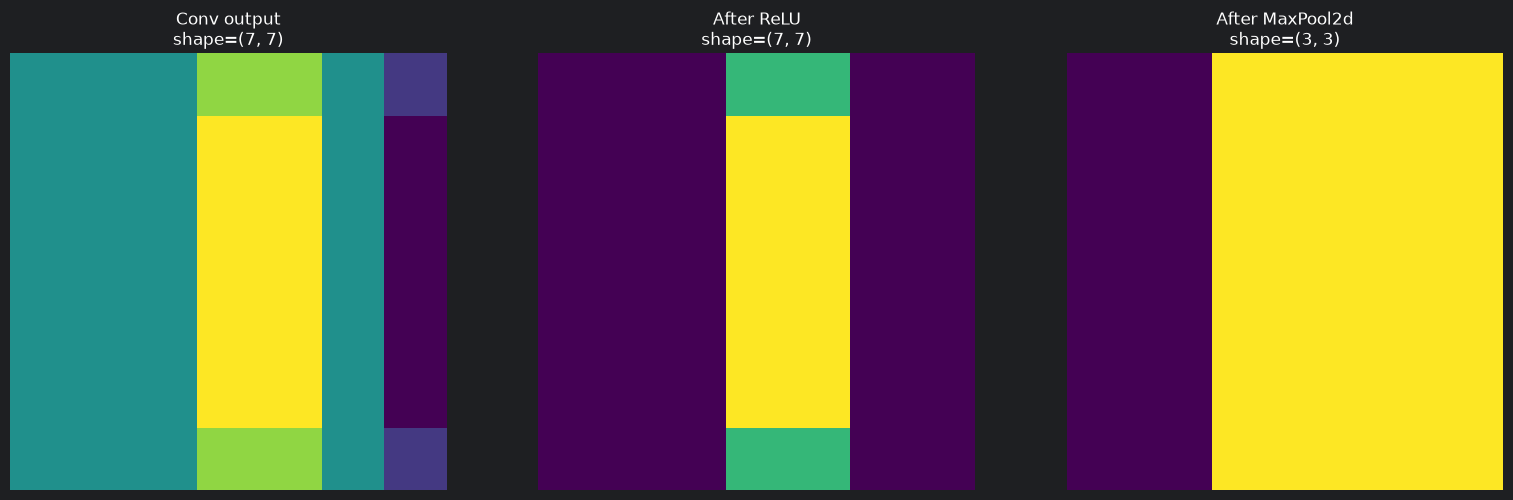

conv: (1, 1, 7, 7)
relu: (1, 1, 7, 7)
pool: (1, 1, 3, 3)


In [5]:
same_feature_map = F.conv2d(
    edge_input,  # (1, 1, 7, 7)
    vertical_edge_kernel,  # 3 x 3 짜리
    padding=1 # 7x7 -> 9x9 (테두리 1px 추가)
    # stride=1 (기본값)
)
# -> 결과 7x7 feature map

# ReLU 활성화 함수
# - 0 이하 수를 모두 0으로 변경(shape 유지)
relu_feature_map = F.relu(same_feature_map)

# 2x2 영역마다 최댓값 하나를 나미고 stride=2 만큼 이동
# -> max_pool 커널이 다가가지 못한 영역은 제외된다
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

# 원본(9x9) -> 커널 통과한 feature map (7x7)
# -> 활성화(7x7) -> max_pool 전달(3x3)
pooled_feature_map = max_pool(relu_feature_map)


figure, axes = plt.subplots(1, 3, figsize=(16, 5))
pooling_steps = [
    (same_feature_map[0, 0], "Conv output"),
    (relu_feature_map[0, 0], "After ReLU"),
    (pooled_feature_map[0, 0], "After MaxPool2d"),
]
for axis, (image, step_name) in zip(axes, pooling_steps):
    axis.imshow(image, cmap="viridis")
    axis.set_title(f"{step_name}\nshape={tuple(image.shape)}")
    axis.axis("off")
plt.tight_layout()
plt.show()

print("conv:", tuple(same_feature_map.shape))
print("relu:", tuple(relu_feature_map.shape))
print("pool:", tuple(pooled_feature_map.shape))

### 5-1. Feature map의 강한 반응 위치와 다음 계층 입력
수직 경계 Kernel의 feature map에서 가장 큰 값을 찾아 입력 이미지의 같은 위치와 비교한다.

이어서 pooling 결과를 다음 Conv2d에 입력해 feature map이 층 사이에서 전달되는 과정을 확인한다.

이는 Kernel이 찾은 특징의 위치와 강도를 저장하고 다음 합성곱층으로 전달하는 과정을 확인하는 것이다.

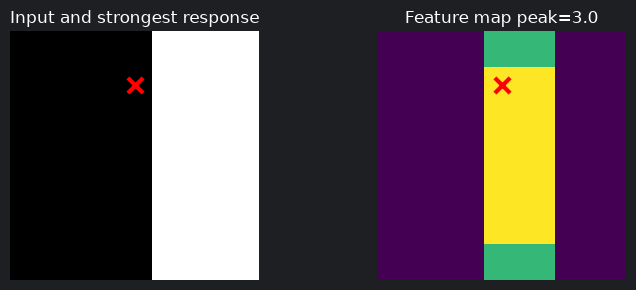

가장 강한 반응 위치: (1, 3)
가장 강한 반응값: 3.0
이전 계층 출력: (1, 1, 3, 3)
다음 Conv2d 출력: (1, 2, 3, 3)


In [6]:
# ReLU를 통과한 첫 번째 이미지·첫 번째 채널의 2차원 feature map을 선택한다.
activation_map = relu_feature_map[0, 0]

# argmax는 가장 큰 활성화값의 1차원 위치를 반환한다.
# divmod로 행과 열을 계산하면 Kernel이 가장 강하게 반응한 공간 위치를 찾을 수 있다.
peak_flat_index = activation_map.argmax().item()
peak_row, peak_column = divmod(peak_flat_index, activation_map.shape[1])
peak_value = activation_map[peak_row, peak_column].item()

figure, axes = plt.subplots(1, 2, figsize=(8, 3))

# 왼쪽에는 원본 입력을 표시하고 feature map의 최대 반응과 대응되는 위치를 붉은 X로 표시한다.
axes[0].imshow(edge_input[0, 0], cmap="gray")
axes[0].scatter(peak_column, peak_row, color="red", marker="x", s=120, linewidths=3)
axes[0].set_title("Input and strongest response")
axes[0].axis("off")

# 오른쪽에는 ReLU 이후 feature map과 최대 활성화 위치를 표시한다.
axes[1].imshow(activation_map, cmap="viridis")
axes[1].scatter(peak_column, peak_row, color="red", marker="x", s=120, linewidths=3)
axes[1].set_title(f"Feature map peak={peak_value:.1f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 이전 계층의 출력 채널 수가 다음 Conv2d의 in_channels가 된다.
# pooled_feature_map은 채널이 1개이므로 다음 계층도 in_channels=1로 정의한다.
next_conv = nn.Conv2d(
    in_channels=1,
    out_channels=2,
    kernel_size=3,
    padding=1,
)

# 별도로 kernel의 가중치를 지정하기 않으면 입력 채녈과 kernel size 범위 내 균등분포한 값으로 초기화 된다
# print(next_conv.weight)

# 다음 계층은 이전 feature map을 입력으로 받아 서로 다른 특징 2개를 만든다.
next_feature_maps = F.relu(next_conv(pooled_feature_map))

print("가장 강한 반응 위치:", (peak_row, peak_column))
print("가장 강한 반응값:", peak_value)
print("이전 계층 출력:", tuple(pooled_feature_map.shape))
print("다음 Conv2d 출력:", tuple(next_feature_maps.shape))

### 6. CNN feature block의 층별 shape 추적

두 개의 Conv-ReLU-Pool 블록을 통과할 때 `(N, C, H, W)`가 층마다 어떻게 변하는지 추적한다.


In [7]:
feature_block = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1), # (32, 8, 28, 28)
    nn.ReLU(), # 활성화 함수, (32, 8 , 28, 28)
    nn.MaxPool2d(kernel_size=2, stride=2), # (32, 8, 14, 14)
    nn.Conv2d(8, 16, kernel_size=3, padding=1), # (32, 16, 14, 14)
    nn.ReLU(), # (32, 16, 14, 14)
    nn.MaxPool2d(kernel_size=2, stride=2), # (32, 16, 7, 7)
)

# FashionMNIST와 같은 규격인 흑백 이미지 32장을 임의 Tensor로 만든다.
fashion_like_batch = torch.randn(32, 1, 28, 28)

block_tensor = fashion_like_batch
print("input", tuple(block_tensor.shape))

# 전체 Sequential을 한 번에 호출하지 않고 계층별로 실행해 중간 shape를 관찰한다.
for layer_index, layer in enumerate(feature_block):
    block_tensor = layer(block_tensor)
    print(layer_index, layer.__class__.__name__, tuple(block_tensor.shape))

input (32, 1, 28, 28)
0 Conv2d (32, 8, 28, 28)
1 ReLU (32, 8, 28, 28)
2 MaxPool2d (32, 8, 14, 14)
3 Conv2d (32, 16, 14, 14)
4 ReLU (32, 16, 14, 14)
5 MaxPool2d (32, 16, 7, 7)


## FC 입력 크기를 하드코딩하지 않는 CNN

### FC와 Flatten
- FC(Fully Connected, 완전 연결) 층은 앞 계층의 모든 값을 연결해 최종 예측을 만드는 계층이며, PyTorch에서는 nn.Linear로 구현한다.

- CNN에서는 합성곱 블록이 만든 (N, C, H, W) feature map을 (N, C×H×W) 벡터로 펼친(Flatten) 뒤 FC 층에 전달하는 방식이 자주 사용된다.

(N, C, H, W) → Flatten → (N, C×H×W) → Linear → logits
하지만 Linear는 입력값의 개수인 in_features가 고정되어야 한다. 예를 들어 (N, 16, 7, 7)을 펼치면 784개이므로 Linear(16×7×7, 10)을 만들 수 있지만, 입력 해상도가 바뀌어 (N, 16, 8, 8)이 되면 1,024개가 되어 shape 오류가 발생한다.

입력 해상도와 앞단 구조가 바뀌면 `Linear(16*7*7, ...)` 같은 숫자는 쉽게 깨진다. `AdaptiveAvgPool2d((1, 1))`를 사용하면 어떤 공간 크기가 들어와도 채널별 대표값 하나로 정리되어 분류층 입력은 채널 수만 알면 된다.


### 7. Adaptive pooling 기반 CNN 정의

입력 해상도가 달라도 완전 연결 층의 입력 크기가 깨지지 않는 CNN을 정의한다.


In [8]:
class ShapeSafeCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        # 입력 이미지 또는 Feature Map의 H, W가 얼마든지 관계없이
        # 채널마다 공간 평균 1개 (1,1)로 만들어서 (N, C, 1, 1)로 고정
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(
            in_features=16,
            out_features=num_classes
        )

    def forward(self, inputs):

        # 합성곱 블록이 (N, 1, H, W) -> (N, 16, H', W') 변환
        feature_maps = self.features(inputs)

        # pool을 이용해 채널별 H' x W' 평균을 계산해서 (N, 16, 1, 1) 변환
        pooled_1x1 = self.pool(feature_maps)

        # FC(완전 연결층 == CNN 신경망층을 통과한 데이터를 평탄화하여 학습하는 층)
        # FC 입력 형식에 맞게 (N, 16, 1, 1)을 (N, 16)으로 펼치기
        feature_vectors = torch.flatten(pooled_1x1, start_dim=1)

        # Linear(16, 10)를 통과시켜 logits(클래스의 원시 점수) 구하기
        logits = self.classifier(feature_vectors)
        return logits

shape_safe_model = ShapeSafeCNN(num_classes=10)
print(shape_safe_model)

ShapeSafeCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=16, out_features=10, bias=True)
)


### 8. 서로 다른 입력 해상도로 모델 계약 검증

28x28과 32x32 입력이 같은 모델에서 모두 10개 클래스 logits로 변환되는지 확인한다.


In [9]:
for image_size in (28, 32):
    dummy_batch = torch.randn(4, 1, image_size, image_size)
    dummy_logits = shape_safe_model(dummy_batch)
    print(f"input={image_size}x{image_size} -> logits={tuple(dummy_logits.shape)}")

trainable_count = sum(
    parameter.numel()
    for parameter in shape_safe_model.parameters()
    if parameter.requires_grad
)
print("trainable parameters:", trainable_count)


input=28x28 -> logits=(4, 10)
input=32x32 -> logits=(4, 10)
trainable parameters: 1418


## 수업 정리

모델을 설계할 때는 각 층의 숫자를 외우기보다 `(N, C, H, W)`를 기록한다. Conv2d의 출력 채널은 커널 수, H와 W는 출력 공식으로 결정되며 pooling은 공간 크기를 줄인다. 입력·커널·feature map을 함께 보고, dummy input 또는 adaptive pooling으로 분류층 연결을 검증하면 shape 오류를 예방할 수 있다.
